<a href="https://colab.research.google.com/github/jasperchen111/gpt-ai-assistant/blob/main/PBFB_BPNN_Part4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
import pandas as pd
import os

# 執行掛載操作，會跳出認證連結
print("--- 執行雲端硬碟掛載 ---")
drive.mount('/content/drive')
print("--- 雲端硬碟掛載完成 ---")

# 定義檔案路徑
# 請根據您的實際檔案位置修改此路徑
file_path = '/content/drive/MyDrive/BPNN_TRAINING_DATA_PHASE.csv'

# 確認檔案是否存在
if not os.path.exists(file_path):
    print(f"\n錯誤：找不到檔案於路徑 {file_path}")
    print("請檢查您的檔案路徑是否正確，或檔案名稱是否大小寫符合。")
else:
    try:
        # 讀取 CSV 檔案
        df_training = pd.read_csv(file_path)

        # 顯示結果
        print(f'\n成功從雲端硬碟路徑載入資料：{file_path}')
        print('\nDataFrame head:')
        display(df_training.head())

    except Exception as e:
        print(f"\n讀取檔案時發生錯誤: {e}")

--- 執行雲端硬碟掛載 ---
Mounted at /content/drive
--- 雲端硬碟掛載完成 ---

成功從雲端硬碟路徑載入資料：/content/drive/MyDrive/BPNN_TRAINING_DATA_PHASE.csv

DataFrame head:


,Time,Vo,Vin,Phase,ID,Vref
0,0.00413,22.698320,380,0.223256,9.530025,22.8
1,0.00414,22.630375,380,0.902719,9.501498,22.8
2,0.00415,22.562634,380,1.580148,9.473057,22.8
3,0.00416,22.495095,380,2.255562,9.444700,22.8
4,0.00417,22.427759,380,2.928956,9.416429,22.8


## Step 1: Data Preparation

First, we'll prepare your data for training. This involves identifying features (inputs) and the target (output), splitting the data into training and testing sets, and scaling the features. For a PSFB PI control, typically `Vin`, `Vo`, and `Vref` would be the inputs, and `Phase` would be the output that the neural network learns to predict based on these inputs. We will drop `Time` and `ID` for this initial model.

In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive # Add drive import here

# Ensure df_training is loaded and non-empty. If not, try to load it.
is_df_training_valid = False
if 'df_training' in locals() or 'df_training' in globals():
    if isinstance(df_training, pd.DataFrame) and not df_training.empty:
        is_df_training_valid = True

if not is_df_training_valid:
    print("Attempting to load/reload df_training as it's not valid in current session.")
    # Explicitly mount drive if df_training is not valid
    print("--- Attempting to mount Google Drive ---")
    drive.mount('/content/drive', force_remount=True)
    print("--- Google Drive mount attempt complete ---")

    file_path = '/content/drive/MyDrive/BPNN_TRAINING_DATA_PHASE.csv' # Define file_path explicitly
    try:
        df_training = pd.read_csv(file_path)
        print(f'Successfully loaded df_training from: {file_path}')
    except FileNotFoundError:
        print(f"Error: The data file was not found at {file_path}. Please ensure Google Drive is mounted and the file exists at the specified path.")
        print("Consider running the first cell (NQjn0aOhdRzc) to mount your Drive and load the data.")
        df_training = pd.DataFrame() # Create an empty DataFrame to prevent further errors
    except Exception as e:
        print(f"An unexpected error occurred while loading df_training: {e}")
        df_training = pd.DataFrame() # Create an empty DataFrame to prevent further errors
else:
    print("df_training is already available and valid in the current session.")

# Check if df_training is still empty after load attempt
if df_training.empty:
    raise ValueError("df_training is empty. Cannot proceed with feature definition. Please resolve the data loading issue by running the first cell (NQjn0aOhdRzc) and verifying the file path.")

# Define features (X) and target (y)
X = df_training[['Vin', 'Vo', 'Vref', 'ID']]
y = df_training['Phase']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation complete!")
print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

df_training is already available and valid in the current session.
Data preparation complete!
Training set size: 823828 samples
Testing set size: 205957 samples


## Step 4: Export Model Parameters to MATLAB

To use the trained BPNN model in MATLAB, we need to export its weights, biases, and the `StandardScaler` parameters (mean and standard deviation). These are crucial for replicating the model's behavior and correctly scaling new input data in MATLAB.

We will use `scipy.io.savemat` to save these parameters into a `.mat` file, which is a native MATLAB data format.

## Step 2: Build and Train the BPNN Model

We will use `MLPRegressor` from `scikit-learn` to implement the Backpropagation Neural Network. You can customize the `hidden_layer_sizes`, `activation` function, `solver`, and `max_iter` as needed.

Here, we'll start with a simple architecture (e.g., one hidden layer with 50 neurons) and a common configuration.

In [3]:
import pandas as pd

# Check if df_training is available
if 'df_training' not in locals() and 'df_training' not in globals():
    print("Error: df_training DataFrame not found. Please ensure the data loading cells (e.g., NQjn0aOhdRzc or f5806365) have been executed.")
else:
    print("--- 檢查電壓範圍是否達到 24V ---")

    # 獲取 Vin, Vo, Vref 的最大值
    max_vin = df_training['Vin'].max()
    max_vo = df_training['Vo'].max()
    max_vref = df_training['Vref'].max()

    print(f"Vin 最大值: {max_vin:.2f}V")
    print(f"Vo 最大值: {max_vo:.2f}V")
    print(f"Vref 最大值: {max_vref:.2f}V")

    # 判斷是否達到 24V
    can_reach_24v_vin = max_vin >= 24
    can_reach_24v_vo = max_vo >= 24
    can_reach_24v_vref = max_vref >= 24

    print(f"Vin 是否能達到 24V: {'是' if can_reach_24v_vin else '否'}")
    print(f"Vo 是否能達到 24V: {'是' if can_reach_24v_vo else '否'}")
    print(f"Vref 是否能達到 24V: {'是' if can_reach_24v_vref else '否'}")

    if can_reach_24v_vin and can_reach_24v_vo and can_reach_24v_vref:
        print("結論: Vin, Vo, Vref 三者都能達到或超過 24V。")
    else:
        print("結論: 至少有一項電壓 (Vin, Vo, Vref) 未達到 24V。")

--- 檢查電壓範圍是否達到 24V ---
Vin 最大值: 420.00V
Vo 最大值: 25.42V
Vref 最大值: 25.20V
Vin 是否能達到 24V: 是
Vo 是否能達到 24V: 是
Vref 是否能達到 24V: 是
結論: Vin, Vo, Vref 三者都能達到或超過 24V。


In [ ]:
from sklearn.neural_network import MLPRegressor

# Initialize the MLP Regressor (BPNN model)
# hidden_layer_sizes: tuple, i-th element represents the number of neurons in the i-th hidden layer.
# activation: Activation function for the hidden layer.
# solver: The algorithm for weight optimization.
# max_iter: Maximum number of iterations.

bpnn_model = MLPRegressor(
    hidden_layer_sizes=(128, 64), # 調整隱藏層結構，增加到兩層，神經元數量分別為 128 和 64
    activation='relu',
    solver='adam',
    max_iter=2000, # 增加最大迭代次數，讓模型有更多收斂機會 (現在會配合 early_stopping)
    alpha=0.0001,  # 新增L2正則化，防止過擬合
    random_state=42,
    early_stopping=True, # 新增提前停止，基於驗證集性能自動停止訓練
    validation_fraction=0.1, # 啟用 early_stopping 時，從訓練數據中分出 10% 作為驗證集
    n_iter_no_change=20, # 在驗證分數沒有改善的連續20個迭代後停止訓練
    verbose=True # Set to True to see training progress
)

# Train the model
bpnn_model.fit(X_train_scaled, y_train)

print("\nBPNN model training complete!")

Iteration 1, loss = 57.63822698
Validation score: 0.060385
Iteration 2, loss = 55.58705567
Validation score: 0.063901
Iteration 3, loss = 55.54213456
Validation score: 0.066011
Iteration 4, loss = 55.45101740
Validation score: 0.068736
Iteration 5, loss = 55.06011541
Validation score: 0.080141
Iteration 6, loss = 54.49304291
Validation score: 0.083929
Iteration 7, loss = 54.24916952
Validation score: 0.088192
Iteration 8, loss = 54.08703779
Validation score: 0.088315
Iteration 9, loss = 53.95699831
Validation score: 0.088115
Iteration 10, loss = 53.84386004
Validation score: 0.091393
Iteration 11, loss = 53.68369124
Validation score: 0.094842
Iteration 12, loss = 53.54094353
Validation score: 0.098642
Iteration 13, loss = 53.50023115
Validation score: 0.090660
Iteration 14, loss = 53.45407004
Validation score: 0.097057
Iteration 15, loss = 53.46023315
Validation score: 0.098354
Iteration 16, loss = 53.44562506
Validation score: 0.098652
Iteration 17, loss = 53.42952491
Validation score

## Step 3: Evaluate the BPNN Model

Now, let's evaluate the trained model using the test set and calculate the requested metrics: MSE, RMSE, MAE, and MAPE. We'll also visualize the 'perfect line' state, which shows how well the predicted values align with the actual values.

--- Attempting to mount Google Drive for ultimate model data load ---
Mounted at /content/drive
--- Google Drive mount attempt complete ---
正在執行修正後的終極優化訓練...

Final MSE: 23.6604
Final MAE: 3.5008


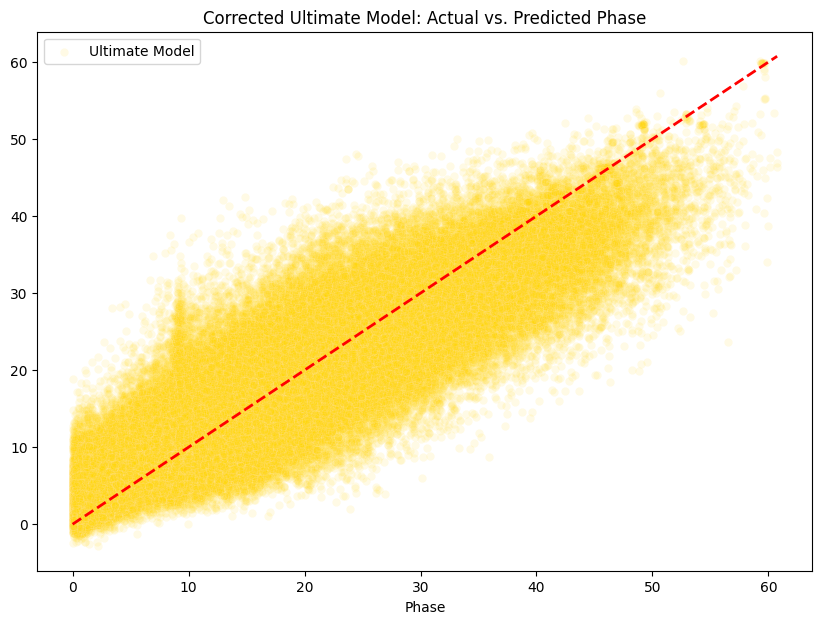

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ensure Google Drive is mounted
print("--- Attempting to mount Google Drive for ultimate model data load ---")
drive.mount('/content/drive', force_remount=True)
print("--- Google Drive mount attempt complete ---")

# 1. 讀取資料
file_path = '/content/drive/MyDrive/BPNN_TRAINING_DATA_PHASE.csv'
df_final_run = pd.read_csv(file_path)

# 2. 完整特徵工程 (Lags + Rolling + Interaction)
df_final_run['V_error'] = df_final_run['Vref'] - df_final_run['Vo']
for lag in [1, 2, 3]:
    df_final_run[f'Vo_lag{lag}'] = df_final_run['Vo'].shift(lag)
    df_final_run[f'V_error_lag{lag}'] = df_final_run['V_error'].shift(lag)
    df_final_run[f'ID_lag{lag}'] = df_final_run['ID'].shift(lag)

df_final_run['Vo_rolling_mean'] = df_final_run['Vo'].rolling(window=5).mean()
df_final_run['V_error_rolling_std'] = df_final_run['V_error'].rolling(window=5).std()
df_final_run['V_error_x_ID'] = df_final_run['V_error'] * df_final_run['ID']
df_final_run = df_final_run.dropna()

# 3. 準備資料
features = ['Vin', 'Vo', 'Vref', 'V_error', 'ID',
            'Vo_lag1', 'V_error_lag1', 'ID_lag1',
            'Vo_lag2', 'V_error_lag2', 'ID_lag2',
            'Vo_lag3', 'V_error_lag3', 'ID_lag3',
            'Vo_rolling_mean', 'V_error_rolling_std', 'V_error_x_ID']

X_final = df_final_run[features]
y_final = df_final_run['Phase']
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# 4. 定義並訓練模型 (Stacking)
estimators = [
    ('xgb', xgb.XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=10, tree_method='hist', random_state=42)),
    ('lgbm', lgb.LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=63, random_state=42))
]
ultimate_model = StackingRegressor(estimators=estimators, final_estimator=RidgeCV(), cv=3, n_jobs=-1)

print("正在執行修正後的終極優化訓練...")
ultimate_model.fit(X_train, y_train)

# 5. 評估
y_pred = ultimate_model.predict(X_test)
print(f'\nFinal MSE: {mean_squared_error(y_test, y_pred):.4f}')
print(f'Final MAE: {mean_absolute_error(y_test, y_pred):.4f}')

# 6. 視覺化
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.1, color='gold', label='Ultimate Model')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Line')
plt.title('Corrected Ultimate Model: Actual vs. Predicted Phase')
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Ensure y_test and y_pred are available from the previous ultimate model run
if 'y_test' not in locals() and 'y_test' not in globals():
    raise ValueError("y_test not found. Please ensure the ultimate model training cell (d9b4dc04) has been executed.")
if 'y_pred' not in locals() and 'y_pred' not in globals():
    raise ValueError("y_pred not found. Please ensure the ultimate model training cell (d9b4dc04) has been executed.")

# Define a robust MAPE calculation function (copied from cell 031873af for consistency)
def calculate_mape_robust(y_true, y_pred, threshold=1e-2):
    # Filter out y_true values that are below the threshold
    non_zero_mask = y_true.abs() > threshold
    if not np.any(non_zero_mask):
        return np.nan # Return NaN if all true values are below the threshold

    y_true_filtered = y_true[non_zero_mask]
    y_pred_filtered = y_pred[non_zero_mask]

    # Avoid division by zero by setting small y_true_filtered values to a tiny non-zero number
    y_true_nz = np.where(y_true_filtered == 0, 1e-8, y_true_filtered)
    return np.mean(np.abs((y_true_filtered - y_pred_filtered) / y_true_nz)) * 100

# Calculate MSE again to ensure consistency and then RMSE
mse_ultimate = mean_squared_error(y_test, y_pred)
rmse_ultimate = np.sqrt(mse_ultimate)

# Calculate MAPE for the ultimate model
mape_ultimate = calculate_mape_robust(y_test, y_pred)

print("--- Ultimate Model Additional Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_ultimate:.4f}") # Re-display for context
print(f"Root Mean Squared Error (RMSE): {rmse_ultimate:.4f}")

if np.isnan(mape_ultimate):
    print(f"Mean Absolute Percentage Error (MAPE): Not applicable (all y_true values below threshold)")
else:
    print(f"Mean Absolute Percentage Error (MAPE) (filtered): {mape_ultimate:.2f}%")


--- Ultimate Model Additional Evaluation ---
Mean Squared Error (MSE): 23.6604
Root Mean Squared Error (RMSE): 4.8642
Mean Absolute Percentage Error (MAPE) (filtered): 78.87%


## Step 12: Stacking Ensemble & Interaction Features
We introduce LightGBM and interaction features, then use a StackingRegressor to merge predictions for maximum accuracy.

In [ ]:
import pandas as pd

# 檢查特徵集 X_final 與目標變數 y_final 中的零值
print("--- 終極模型數據集 (X_final & y_final) 零值檢查 ---")

# 1. 檢查目標變數 Phase
y_zeros = (y_final == 0).sum()
y_min = y_final.min()
print(f"[Phase] 數值為 0 的數量: {y_zeros}")
print(f"[Phase] 最小值: {y_min:.10f}")

# 2. 檢查所有輸入特徵
print("\n[各項特徵] 數值為 0 的統計:")
features_zero_count = (X_final == 0).sum()
display(features_zero_count[features_zero_count > 0] if (features_zero_count > 0).any() else "所有特徵皆無 0 值")

# 3. 檢查是否存在極小值 (小於 1e-6)
small_threshold = 1e-6
small_values = (X_final.abs() < small_threshold) & (X_final != 0)
print(f"\n[極小值檢查] 絕對值小於 {small_threshold} 且不為 0 的特徵數量:")
print(small_values.sum().sum())

--- 終極模型數據集 (X_final & y_final) 零值檢查 ---
[Phase] 數值為 0 的數量: 0
[Phase] 最小值: 0.0000096490

[各項特徵] 數值為 0 的統計:


'所有特徵皆無 0 值'


[極小值檢查] 絕對值小於 1e-06 且不為 0 的特徵數量:
4


### Analyzing the `y_test` distribution

Let's check the descriptive statistics and distribution of `y_test` to understand if many values are close to zero, which could explain the high MAPE.

Descriptive statistics for y_test (Actual Phase values):


,Phase
count,205957.000000
mean,16.113652
std,10.894742
min,0.000136
25%,8.652288
50%,13.440092
75%,22.668408
max,60.749136


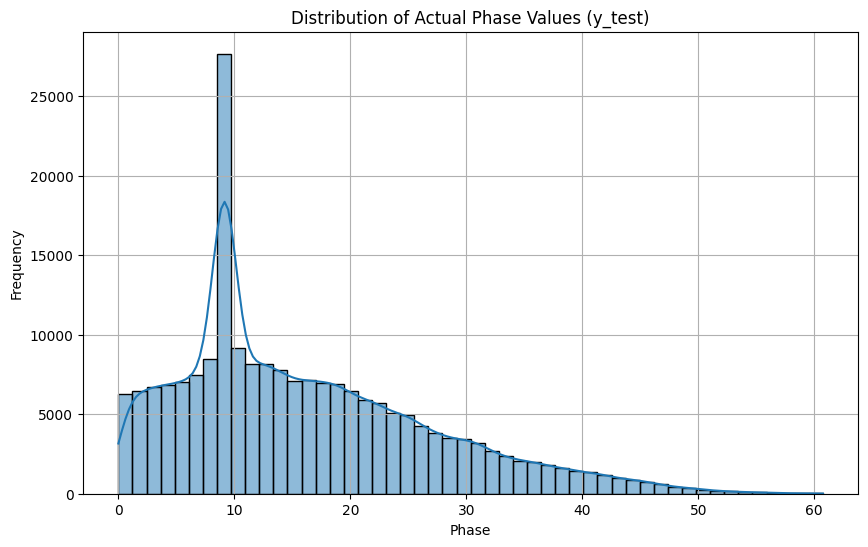


Number of y_test values less than 1.0: 5152 (2.50%) 


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Display descriptive statistics for y_test
print("Descriptive statistics for y_test (Actual Phase values):")
display(y_test.describe())

# Plot histogram of y_test
plt.figure(figsize=(10, 6))
sns.histplot(y_test, bins=50, kde=True)
plt.title('Distribution of Actual Phase Values (y_test)')
plt.xlabel('Phase')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Count values close to zero (e.g., less than a threshold)
threshold = 1.0 # Define a threshold for 'close to zero'
num_small_values = (y_test < threshold).sum()
percentage_small_values = (num_small_values / len(y_test)) * 100

print(f"\nNumber of y_test values less than {threshold}: {num_small_values} ({percentage_small_values:.2f}%) ")

In [ ]:
# 檢查 Phase 欄位中的 0 值與極小值
zero_count = (df_training['Phase'] == 0).sum()
small_value_threshold = 1e-5
near_zero_count = (df_training['Phase'].abs() < small_value_threshold).sum()

print(f"--- Phase 欄位數值檢查 ---")
print(f"數值正好為 0 的樣本數: {zero_count}")
print(f"絕對值小於 {small_value_threshold} 的樣本數: {near_zero_count}")
print(f"Phase 最小值: {df_training['Phase'].min()}")

if zero_count > 0 or near_zero_count > 0:
    print("\n注意：偵測到 0 或極小值，這會導致 MAPE 變得異常高。")

NameError: name 'df_training' is not defined

/tmp/ipykernel_451/809645274.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


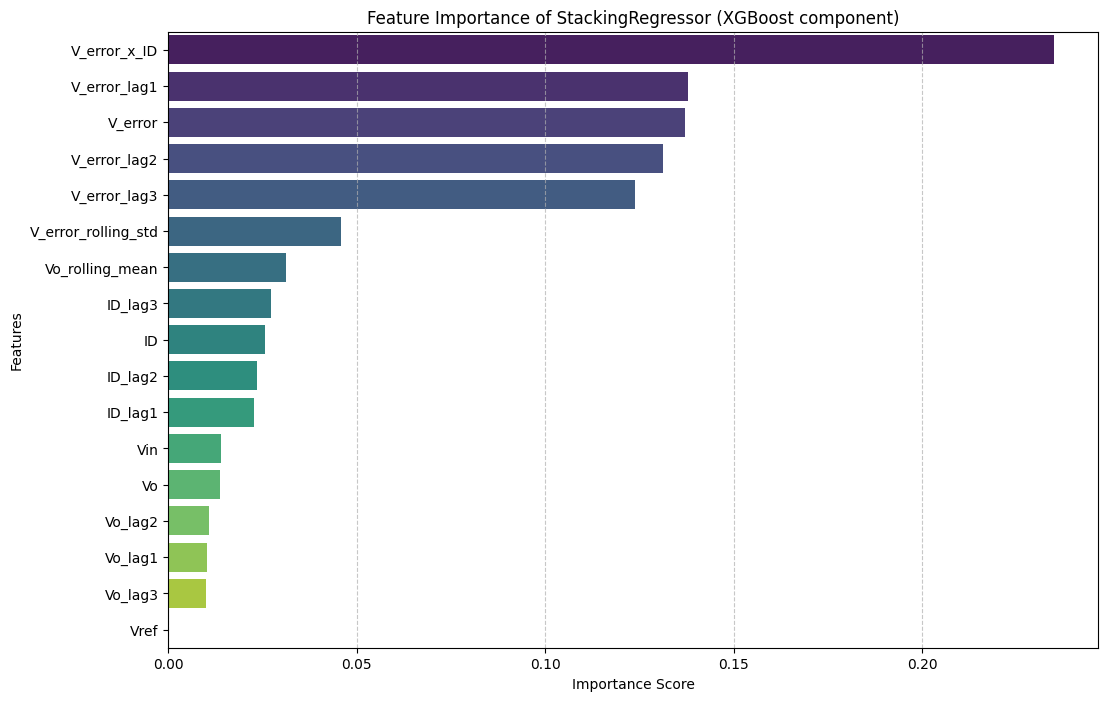

--- 特徵重要性排名 ---


,Feature,Importance
16,V_error_x_ID,0.234999
6,V_error_lag1,0.137837
3,V_error,0.137018
9,V_error_lag2,0.131295
12,V_error_lag3,0.123769
15,V_error_rolling_std,0.045778
14,Vo_rolling_mean,0.031215
13,ID_lag3,0.027165
4,ID,0.025712
10,ID_lag2,0.023501


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 檢查 ultimate_model 是否存在
if 'ultimate_model' not in locals() and 'ultimate_model' not in globals():
    raise ValueError("ultimate_model not found. Please ensure the model training cell (d9b4dc04) has been executed.")

# 1. 取得特徵重要性數值
# 從 StackingRegressor 中提取 XGBoost 模型的 feature_importances_
# 假設 XGBoost 在 StackingRegressor 中被命名為 'xgb'
importance_values = ultimate_model.named_estimators_['xgb'].feature_importances_

# 確保 features 變數存在，它應該在 d9b4dc04 中被定義
if 'features' not in locals() and 'features' not in globals():
    raise ValueError("features list not found. Please ensure the data preparation cell (d9b4dc04) has been executed.")
feature_names = features # 使用之前定義的 features 列表

# 2. 建立 DataFrame 方便繪圖
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_values})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# 3. 視覺化
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Feature Importance of StackingRegressor (XGBoost component)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. 顯示數值列表
print("--- 特徵重要性排名 ---")
display(fi_df)

## Step 10: Model Saving and Prediction Example
We use `joblib` to save the model and provide a function for future inference.

In [ ]:
import joblib

# 檢查 ultimate_model 是否存在
if 'ultimate_model' not in locals() and 'ultimate_model' not in globals():
    raise ValueError("ultimate_model not found. Please ensure the model training cell (d9b4dc04) has been executed.")

# 1. 保存模型與 Scaler
joblib.dump(ultimate_model, 'best_phase_model.pkl')
# 注意：若有使用 scaler，也需保存
# joblib.dump(scaler, 'data_scaler.pkl') # 目前的 ultimate_model 沒有獨立的 scaler, 如果有必要，需要單獨保存X_final的 StandardScaler

print("模型已保存為 best_phase_model.pkl")

# 2. 單次預測範例函數
def predict_phase(input_data):
    """
    input_data: 包含所有 14 個特徵的 DataFrame (Vin, Vo, Vref, V_error, ID, 以及 Lag 1-3)
    """
    prediction = ultimate_model.predict(input_data)
    return prediction[0]

# 測試顯示一筆測試集中的資料預測結果
# 確保 X_test 和 y_test 變數存在，它應該在 d9b4dc04 中被定義
if 'X_test' not in locals() and 'X_test' not in globals():
    raise ValueError("X_test not found. Please ensure the data preparation cell (d9b4dc04) has been executed.")
if 'y_test' not in locals() and 'y_test' not in globals():
    raise ValueError("y_test not found. Please ensure the data preparation cell (d9b4dc04) has been executed.")

test_sample = X_test.iloc[[0]]
actual_val = y_test.iloc[0]
pred_val = predict_phase(test_sample)

print(f"\n範例測試：")
print(f"實際值 (Actual): {actual_val:.4f}")
print(f"預測值 (Predicted): {pred_val:.4f}")
print(f"誤差 (Error): {abs(actual_val - pred_val):.4f}")

模型已保存為 best_phase_model.pkl

範例測試：
實際值 (Actual): 14.7310
預測值 (Predicted): 21.5914
誤差 (Error): 6.8603
